# Fixing content preservation — an experiment

`02_model.ipynb`'s ablation identified content preservation (BoW word-presence F1 between the original recipe and its style-transferred version) as the project's main weak point: **0.25** with the adversarial loss on, **0.37** with it off — weak either way, pointing to a more fundamental limitation than the adversarial mechanism alone.

This notebook bundles together **five changes** into a single new model, trained from scratch, to see whether they move that number:

1. **Attention** — the decoder now attends over every encoder timestep's content-projected state, instead of decoding from a single fixed content vector.
2. **A copy/pointer mechanism** — at every decode step the model can directly copy a word from the source recipe (via the attention distribution) instead of only generating from the vocabulary softmax.
3. **A bigger content latent** — `hidden_dim` 512 → 768 (content_dim 448 → 704), so content has more room to avoid being squeezed.
4. **Retuned adversarial loss weight** — 2.0 → 1.0 (equal to the style/content loss weight, was previously double it), trading a bit of disentanglement strength for content fidelity.
5. **Teacher-forcing decay** — a fixed 0.5 ratio → linear decay from 0.9 to 0.1 across epochs, so the model gets used to relying on its own (possibly wrong) previous output before it has to do so at inference/eval time.

This is a separate, self-contained experiment: it reuses the artifacts from `01_preprocessing.ipynb` (train/val/test splits, Word2Vec, the BoW vectorizer) but trains its own model, its own checkpoint, and its own style vectors under different filenames — nothing from `02_model.ipynb`'s pipeline or its saved checkpoint is modified.

At the end, the *original* best checkpoint is reloaded and re-scored fresh (same held-out sample, same independent evaluation classifier) so the before/after comparison is apples-to-apples, not just copied numbers from the README.

## Load the preprocessed artifacts (same as `02_model.ipynb`)

In [1]:
import ast
import os

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from gensim.models import KeyedVectors
from torch.utils.data import Dataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

def load_split(name):
    df = pd.read_csv(f'./data/recipes_{name}.csv', index_col=0)
    df['steps_tokens'] = df['steps_tokens'].apply(ast.literal_eval)
    df['steps_tokens_bow'] = df['steps_tokens_bow'].apply(ast.literal_eval)
    return df

train_df = load_split('train')
val_df = load_split('val')
test_df = load_split('test')

df_final = pd.read_csv('./data/recipes_final.csv', index_col=0)[['name', 'steps']]

wv = KeyedVectors.load('./data/models/word2vec.wordvectors')

def identity_analyzer(tokens):
    return tokens

vectorizer = joblib.load('./data/models/bow_vectorizer.joblib')

X_train_bow = vectorizer.transform(train_df['steps_tokens_bow'])
X_val_bow = vectorizer.transform(val_df['steps_tokens_bow'])
X_test_bow = vectorizer.transform(test_df['steps_tokens_bow'])

print(train_df.shape, val_df.shape, test_df.shape)

mps
(8637, 3) (1851, 3) (1851, 3)


In [2]:
seq_len = int(train_df['steps_tokens'].apply(len).quantile(0.95))
input_dim = wv.vector_size
print('seq_len:', seq_len, '| input_dim:', input_dim)

def tokens_to_matrix(tokens, wv, seq_len):
    matrix = np.zeros((seq_len, wv.vector_size), dtype=np.float32)
    for i, token in enumerate(tokens[:seq_len]):
        if token in wv:
            matrix[i] = wv[token]
    return matrix

PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN = '<PAD>', '<UNK>', '<SOS>', '<EOS>'
word2idx = dict(wv.key_to_index)
word2idx[PAD_TOKEN] = len(word2idx)
PAD_IDX = word2idx[PAD_TOKEN]
word2idx[UNK_TOKEN] = len(word2idx)
UNK_IDX = word2idx[UNK_TOKEN]
word2idx[SOS_TOKEN] = len(word2idx)
SOS_IDX = word2idx[SOS_TOKEN]
word2idx[EOS_TOKEN] = len(word2idx)
EOS_IDX = word2idx[EOS_TOKEN]
VOCAB_SIZE = len(word2idx)
idx2word = {idx: word for word, idx in word2idx.items()}

def tokens_to_indices(tokens, word2idx, seq_len):
    tokens = tokens[:seq_len - 1]
    indices = [word2idx.get(t, UNK_IDX) for t in tokens]
    indices.append(EOS_IDX)
    indices += [PAD_IDX] * (seq_len - len(indices))
    return indices

def indices_to_tokens(indices):
    tokens = []
    for i in indices:
        if i == EOS_IDX:
            break
        if i != PAD_IDX:
            tokens.append(idx2word[i])
    return tokens

CUISINE2IDX = {'Italian': 0, 'Indian': 1}
IDX2CUISINE = {idx: name for name, idx in CUISINE2IDX.items()}
BOW_VOCAB_SIZE = X_train_bow.shape[1]
NO_REPEAT_NGRAM_SIZE = 3

seq_len: 223 | input_dim: 150


In [3]:
class RecipeDataset(Dataset):
    def __init__(self, df, wv, word2idx, seq_len, cuisine2idx, bow_matrix):
        self.tokens = df['steps_tokens'].tolist()
        self.cuisines = df['cuisine'].tolist()
        self.wv = wv
        self.word2idx = word2idx
        self.seq_len = seq_len
        self.cuisine2idx = cuisine2idx
        self.bow_matrix = bow_matrix

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        tokens = self.tokens[idx]
        x = tokens_to_matrix(tokens, self.wv, self.seq_len)
        y = tokens_to_indices(tokens, self.word2idx, self.seq_len)
        length = max(1, min(len(tokens), self.seq_len))
        style_label = self.cuisine2idx[self.cuisines[idx]]
        bow_target = (self.bow_matrix[idx].toarray().ravel() > 0).astype(np.float32)
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(style_label, dtype=torch.long),
            torch.tensor(bow_target, dtype=torch.float32),
        )

BATCH_SIZE = 32
train_dataset = RecipeDataset(train_df, wv, word2idx, seq_len, CUISINE2IDX, X_train_bow)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = RecipeDataset(val_df, wv, word2idx, seq_len, CUISINE2IDX, X_val_bow)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_dataset = RecipeDataset(test_df, wv, word2idx, seq_len, CUISINE2IDX, X_test_bow)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

## Change 1 & 3: attention-ready encoder with a bigger content latent

The encoder now also returns **per-timestep** content-projected states (`content_states`), not just the pooled final-hidden-state split. It reuses the *same* `content_head` linear layer for both the pooled `content_latent` and every timestep's state, so the decoder's attention operates in the same "content space" the rest of the model already uses — it never gets to see anything the disentanglement mechanism would call "style".

`hidden_dim` goes from 512 to 768 (content_dim 448 → 704) — change 3, more room for content.

In [4]:
class GRUEncoderAttn(nn.Module):
    def __init__(self, input_dim, hidden_dim, style_dim, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.style_dim = style_dim
        self.content_dim = hidden_dim - style_dim
        self.style_head = nn.Linear(hidden_dim, style_dim)
        self.content_head = nn.Linear(hidden_dim, self.content_dim)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, hidden = self.gru(packed)
        # unpack to get every timestep's hidden state (not just the final one) for attention;
        # total_length pins the output back to the fixed seq_len so shapes stay consistent
        # across batches regardless of that batch's longest real sequence
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
        outputs = self.dropout(outputs)
        hidden = hidden.squeeze(0)
        hidden = self.dropout(hidden)
        style_latent = self.style_head(hidden)
        content_latent = self.content_head(hidden)
        content_states = self.content_head(outputs)  # per-position content projection, same head as above
        return style_latent, content_latent, content_states

hidden_dim = 768
STYLE_DIM = 64
encoder = GRUEncoderAttn(input_dim, hidden_dim, STYLE_DIM, dropout=0.2).to(device)
print('content_dim:', encoder.content_dim, '(was 448 in the baseline model)')

content_dim: 704 (was 448 in the baseline model)


## Change 2: attention + pointer/copy decoder

At every decode step:
1. Score the current GRU hidden state against every (masked, padding-excluded) `content_state` and take a softmax → attention weights over source positions.
2. Use those weights both as a **context vector** (weighted sum of `content_states`, concatenated into the vocabulary-generation layer) and as a **copy distribution** — scattered into vocabulary space by each source position's own token id, since decoding is autoencoding-shaped (the source recipe's own tokens are always known, whether we're reconstructing it during training or transferring it to another cuisine at inference).
3. A small `p_gen` gate (sigmoid, conditioned on hidden state + context + current input embedding) mixes the two: `final = p_gen * generate + (1 - p_gen) * copy`.

Because the mixing happens in probability space, the reconstruction loss becomes `NLLLoss` on `log(final_probs)` instead of `CrossEntropyLoss` on raw logits — both are still `-log p(true token)` in nats, so loss values stay directly comparable to the baseline model's.

In [5]:
class AttnPointerGRUDecoder(nn.Module):
    def __init__(self, hidden_dim, content_dim, vocab_size, embed_dim, sos_idx, pad_idx, unk_idx, max_len, dropout=0.2):
        super().__init__()
        self.max_len = max_len
        self.sos_idx = sos_idx
        self.unk_idx = unk_idx
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.gru_cell = nn.GRUCell(embed_dim, hidden_dim)
        self.attn_proj = nn.Linear(content_dim, hidden_dim, bias=False)
        self.fc_out = nn.Linear(hidden_dim + content_dim, vocab_size)
        self.p_gen = nn.Linear(hidden_dim + content_dim + embed_dim, 1)

    def forward(self, hidden, content_states, source_ids, mask, target=None,
                teacher_forcing_ratio=0.5, no_repeat_ngram_size=0):
        batch_size = hidden.size(0)
        device = hidden.device
        max_len = target.size(1) if target is not None else self.max_len
        eps = 1e-9

        # content_states don't change across decode steps, so project them for attention scoring once
        projected_states = self.attn_proj(content_states)          # (batch, seq_len, hidden_dim)
        neg_inf_mask = (~mask).float() * -1e9                      # additive mask, blocks padding positions

        input_idx = torch.full((batch_size,), self.sos_idx, dtype=torch.long, device=device)
        h = hidden
        log_probs_out = []
        generated = [[] for _ in range(batch_size)] if no_repeat_ngram_size > 0 else None

        for t in range(max_len):
            embedded = self.embedding(input_idx)
            embedded = self.dropout(embedded)
            h = self.gru_cell(embedded, h)

            scores = torch.bmm(projected_states, h.unsqueeze(-1)).squeeze(-1) + neg_inf_mask
            attn_weights = torch.softmax(scores, dim=-1)                              # (batch, seq_len)
            context = torch.bmm(attn_weights.unsqueeze(1), content_states).squeeze(1)  # (batch, content_dim)

            vocab_logits = self.fc_out(torch.cat([h, context], dim=-1))
            vocab_probs = torch.softmax(vocab_logits, dim=-1)
            p_gen = torch.sigmoid(self.p_gen(torch.cat([h, context, embedded], dim=-1)))  # (batch, 1)

            # scatter the attention distribution into vocab space by each source position's token id -
            # positions that happen to share a word id have their attention mass summed together there
            copy_probs = torch.zeros_like(vocab_probs)
            copy_probs.scatter_add_(1, source_ids, attn_weights)

            final_probs = p_gen * vocab_probs + (1 - p_gen) * copy_probs

            if target is None:
                # pure free-running generation (not a training step that merely wasn't teacher-forced
                # this time): never emit <UNK>, and enforce no-repeat-trigram blocking directly on the
                # final mixed distribution so it applies regardless of whether a token came from
                # generation or copying
                final_probs = final_probs.clone()
                final_probs[:, self.unk_idx] = 0.0
                if no_repeat_ngram_size > 0:
                    for b in range(batch_size):
                        seq = generated[b]
                        if seq:
                            final_probs[b, seq[-1]] = 0.0
                        if len(seq) >= no_repeat_ngram_size - 1:
                            prefix = tuple(seq[-(no_repeat_ngram_size - 1):])
                            for i in range(len(seq) - no_repeat_ngram_size + 1):
                                if tuple(seq[i:i + no_repeat_ngram_size - 1]) == prefix:
                                    final_probs[b, seq[i + no_repeat_ngram_size - 1]] = 0.0
                final_probs = final_probs / final_probs.sum(dim=-1, keepdim=True).clamp_min(eps)

            log_probs_out.append(torch.log(final_probs.clamp_min(eps)).unsqueeze(1))

            use_teacher_forcing = target is not None and torch.rand(1).item() < teacher_forcing_ratio
            if use_teacher_forcing:
                input_idx = target[:, t]
            else:
                input_idx = final_probs.argmax(dim=-1)
                if no_repeat_ngram_size > 0 and target is None:
                    for b in range(batch_size):
                        generated[b].append(input_idx[b].item())

        return torch.cat(log_probs_out, dim=1)  # (batch, max_len, vocab_size) log-probabilities

decoder = AttnPointerGRUDecoder(
    hidden_dim, encoder.content_dim, VOCAB_SIZE, input_dim, SOS_IDX, PAD_IDX, UNK_IDX, seq_len, dropout=0.2
).to(device)

## Combined autoencoder wrapper

In [6]:
class Seq2SeqAutoencoderAttn(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x, lengths, source_ids, target=None, teacher_forcing_ratio=0.5,
                no_repeat_ngram_size=0, return_latents=False):
        style_latent, content_latent, content_states = self.encoder(x, lengths)
        seq_len_ = content_states.size(1)
        # cap the attendable/copyable region at seq_len-1: steps_to_indices reserves the last
        # slot for <EOS>, so this keeps source_ids' real-token region aligned with content_states'
        mask_len = lengths.clamp(max=seq_len_ - 1).to(content_states.device)
        mask = torch.arange(seq_len_, device=content_states.device).unsqueeze(0) < mask_len.unsqueeze(1)
        hidden0 = torch.cat([style_latent, content_latent], dim=-1)
        log_probs = self.decoder(
            hidden0, content_states, source_ids, mask,
            target=target, teacher_forcing_ratio=teacher_forcing_ratio,
            no_repeat_ngram_size=no_repeat_ngram_size,
        )
        if return_latents:
            return log_probs, style_latent, content_latent
        return log_probs

model = Seq2SeqAutoencoderAttn(encoder, decoder).to(device)

## Change 4: classifiers + retuned adversarial weight

Same four classifier heads and same entropy-maximization mechanism as `02_model.ipynb` — only the loss weights change (`ADV_STYLE_LOSS_WEIGHT`/`ADV_CONTENT_LOSS_WEIGHT`: 2.0 → 1.0, now equal to the style/content weight instead of double it).

In [7]:
style_classifier = nn.Linear(STYLE_DIM, len(CUISINE2IDX)).to(device)
content_classifier = nn.Sequential(
    nn.Linear(encoder.content_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, BOW_VOCAB_SIZE)
).to(device)
adv_style_classifier = nn.Sequential(
    nn.Linear(encoder.content_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, len(CUISINE2IDX))
).to(device)
adv_content_classifier = nn.Sequential(
    nn.Linear(encoder.style_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, BOW_VOCAB_SIZE)
).to(device)

recon_criterion = nn.NLLLoss(ignore_index=PAD_IDX)  # decoder now outputs log-probabilities, not logits
style_criterion = nn.CrossEntropyLoss()
content_criterion = nn.BCEWithLogitsLoss()
adv_style_criterion = nn.CrossEntropyLoss()
adv_content_criterion = nn.BCEWithLogitsLoss()

def categorical_entropy(logits):
    log_probs = torch.log_softmax(logits, dim=-1)
    return -(log_probs.exp() * log_probs).sum(dim=-1).mean()

def bernoulli_entropy(logits):
    log_p = F.logsigmoid(logits)
    log_1m_p = F.logsigmoid(-logits)
    p = log_p.exp()
    return -(p * log_p + (1 - p) * log_1m_p).mean(dim=-1).mean()

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(style_classifier.parameters()) + list(content_classifier.parameters()),
    lr=1e-3, weight_decay=1e-5,
)
adv_style_optimizer = torch.optim.RMSprop(adv_style_classifier.parameters(), lr=1e-3)
adv_content_optimizer = torch.optim.RMSprop(adv_content_classifier.parameters(), lr=1e-3)

@torch.no_grad()
def evaluate_val_recon_loss_attn(model, val_loader, device):
    was_training = model.training
    model.eval()
    total = 0.0
    for batch_x, batch_y, batch_len, _, _ in val_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        log_probs = model(batch_x, batch_len, source_ids=batch_y, target=batch_y, teacher_forcing_ratio=0.0)
        total += recon_criterion(log_probs.permute(0, 2, 1), batch_y).item()
    if was_training:
        model.train()
    return total / len(val_loader)

CHECKPOINT_PATH = './data/models/checkpoint_attn_pointer.pt'
BEST_RECON_CHECKPOINT_PATH = './data/models/checkpoint_attn_pointer_best_recon.pt'
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

def make_checkpoint(epoch, best_recon_loss):
    return {
        'epoch': epoch,
        'best_recon_loss': best_recon_loss,
        'model': model.state_dict(),
        'style_classifier': style_classifier.state_dict(),
        'content_classifier': content_classifier.state_dict(),
        'adv_style_classifier': adv_style_classifier.state_dict(),
        'adv_content_classifier': adv_content_classifier.state_dict(),
        'hparams': {
            'input_dim': input_dim, 'hidden_dim': hidden_dim, 'style_dim': STYLE_DIM,
            'vocab_size': VOCAB_SIZE, 'bow_vocab_size': BOW_VOCAB_SIZE, 'seq_len': seq_len,
            'pad_idx': PAD_IDX, 'sos_idx': SOS_IDX, 'unk_idx': UNK_IDX,
        },
    }

## Change 5: teacher-forcing decay, and the training loop

`TEACHER_FORCING_RATIO` is no longer a constant — it decays linearly from 0.9 (epoch 1) to 0.1 (the final epoch), so the model is gradually weaned off ground-truth previous tokens and has to get good at continuing from its *own* (possibly imperfect) generations, matching how it's actually used at inference/transfer time.

Same early-stopping-on-validation-recon-loss setup as `02_model.ipynb`, same epoch budget, so the two models get a comparable training effort.

In [8]:
NUM_EPOCHS = 20
TEACHER_FORCING_START = 0.9
TEACHER_FORCING_END = 0.1
STYLE_LOSS_WEIGHT = 1.0
CONTENT_LOSS_WEIGHT = 1.0
ADV_STYLE_LOSS_WEIGHT = 1.0     # was 2.0 in the baseline model
ADV_CONTENT_LOSS_WEIGHT = 1.0   # was 2.0 in the baseline model
EARLY_STOPPING_PATIENCE = 5

best_recon_loss = float('inf')
patience_counter = 0
loss_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    teacher_forcing_ratio = TEACHER_FORCING_START + (TEACHER_FORCING_END - TEACHER_FORCING_START) * (epoch - 1) / (NUM_EPOCHS - 1)

    model.train()
    style_classifier.train()
    content_classifier.train()
    adv_style_classifier.train()
    adv_content_classifier.train()
    total_loss = total_recon_loss = total_style_loss = total_content_loss = 0.0
    total_adv_style_encoder_loss = total_adv_content_encoder_loss = 0.0
    total_adv_style_clf_loss = total_adv_content_clf_loss = 0.0
    correct_adv_style = total_adv = 0

    for batch_x, batch_y, batch_len, batch_style, batch_bow in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        batch_style, batch_bow = batch_style.to(device), batch_bow.to(device)
        optimizer.zero_grad()

        log_probs, style_latent, content_latent = model(
            batch_x, batch_len, source_ids=batch_y, target=batch_y,
            teacher_forcing_ratio=teacher_forcing_ratio, return_latents=True,
        )
        recon_loss = recon_criterion(log_probs.permute(0, 2, 1), batch_y)

        style_logits = style_classifier(style_latent)
        style_loss = style_criterion(style_logits, batch_style)

        content_logits = content_classifier(content_latent)
        content_loss = content_criterion(content_logits, batch_bow)

        adv_style_encoder_loss = -categorical_entropy(adv_style_classifier(content_latent))
        adv_content_encoder_loss = -bernoulli_entropy(adv_content_classifier(style_latent))

        loss = (
            recon_loss
            + STYLE_LOSS_WEIGHT * style_loss
            + CONTENT_LOSS_WEIGHT * content_loss
            + ADV_STYLE_LOSS_WEIGHT * adv_style_encoder_loss
            + ADV_CONTENT_LOSS_WEIGHT * adv_content_encoder_loss
        )
        loss.backward()
        optimizer.step()

        adv_style_optimizer.zero_grad()
        adv_style_clf_logits = adv_style_classifier(content_latent.detach())
        adv_style_clf_loss = adv_style_criterion(adv_style_clf_logits, batch_style)
        adv_style_clf_loss.backward()
        adv_style_optimizer.step()

        adv_content_optimizer.zero_grad()
        adv_content_clf_loss = adv_content_criterion(adv_content_classifier(style_latent.detach()), batch_bow)
        adv_content_clf_loss.backward()
        adv_content_optimizer.step()

        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_style_loss += style_loss.item()
        total_content_loss += content_loss.item()
        total_adv_style_encoder_loss += adv_style_encoder_loss.item()
        total_adv_content_encoder_loss += adv_content_encoder_loss.item()
        total_adv_style_clf_loss += adv_style_clf_loss.item()
        total_adv_content_clf_loss += adv_content_clf_loss.item()
        correct_adv_style += (adv_style_clf_logits.argmax(dim=-1) == batch_style).sum().item()
        total_adv += batch_style.size(0)

    n_batches = len(train_loader)
    avg_recon_loss = total_recon_loss / n_batches
    avg_adv_style_clf_acc = correct_adv_style / total_adv
    val_recon_loss = evaluate_val_recon_loss_attn(model, val_loader, device)
    print(
        f'epoch {epoch}/{NUM_EPOCHS} | tf_ratio {teacher_forcing_ratio:.2f} '
        f'| loss {total_loss / n_batches:.4f} | recon {avg_recon_loss:.4f} | val_recon {val_recon_loss:.4f} '
        f'| style {total_style_loss / n_batches:.4f} | content {total_content_loss / n_batches:.4f} '
        f'| adv_style_clf_acc {avg_adv_style_clf_acc:.4f}'
    )

    loss_history.append({
        'epoch': epoch, 'recon_loss': avg_recon_loss, 'val_recon_loss': val_recon_loss,
        'adv_style_clf_acc': avg_adv_style_clf_acc, 'teacher_forcing_ratio': teacher_forcing_ratio,
    })

    if val_recon_loss < best_recon_loss:
        best_recon_loss = val_recon_loss
        patience_counter = 0
        torch.save(make_checkpoint(epoch, best_recon_loss), BEST_RECON_CHECKPOINT_PATH)
        print(f'  -> new best val recon loss {best_recon_loss:.4f}, saved to {BEST_RECON_CHECKPOINT_PATH}')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'  -> val recon loss has not improved for {EARLY_STOPPING_PATIENCE} epochs, stopping early')
            break

torch.save(make_checkpoint(epoch, best_recon_loss), CHECKPOINT_PATH)

best_checkpoint = torch.load(BEST_RECON_CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(best_checkpoint['model'])
style_classifier.load_state_dict(best_checkpoint['style_classifier'])
content_classifier.load_state_dict(best_checkpoint['content_classifier'])
adv_style_classifier.load_state_dict(best_checkpoint['adv_style_classifier'])
adv_content_classifier.load_state_dict(best_checkpoint['adv_content_classifier'])

epoch 1/20 | tf_ratio 0.90 | loss 0.4219 | recon 0.5771 | val_recon 4.2930 | style 0.3484 | content 0.0377 | adv_style_clf_acc 0.6832
  -> new best val recon loss 4.2930, saved to ./data/models/checkpoint_attn_pointer_best_recon.pt
epoch 2/20 | tf_ratio 0.86 | loss -0.1989 | recon 0.1108 | val_recon 2.3839 | style 0.1912 | content 0.0192 | adv_style_clf_acc 0.6765
  -> new best val recon loss 2.3839, saved to ./data/models/checkpoint_attn_pointer_best_recon.pt
epoch 3/20 | tf_ratio 0.82 | loss -0.3071 | recon 0.0893 | val_recon 1.7660 | style 0.1372 | content 0.0188 | adv_style_clf_acc 0.6807
  -> new best val recon loss 1.7660, saved to ./data/models/checkpoint_attn_pointer_best_recon.pt
epoch 4/20 | tf_ratio 0.77 | loss -0.3357 | recon 0.0901 | val_recon 1.4771 | style 0.0997 | content 0.0185 | adv_style_clf_acc 0.6681
  -> new best val recon loss 1.4771, saved to ./data/models/checkpoint_attn_pointer_best_recon.pt
epoch 5/20 | tf_ratio 0.73 | loss -0.3535 | recon 0.0941 | val_recon 

<All keys matched successfully>

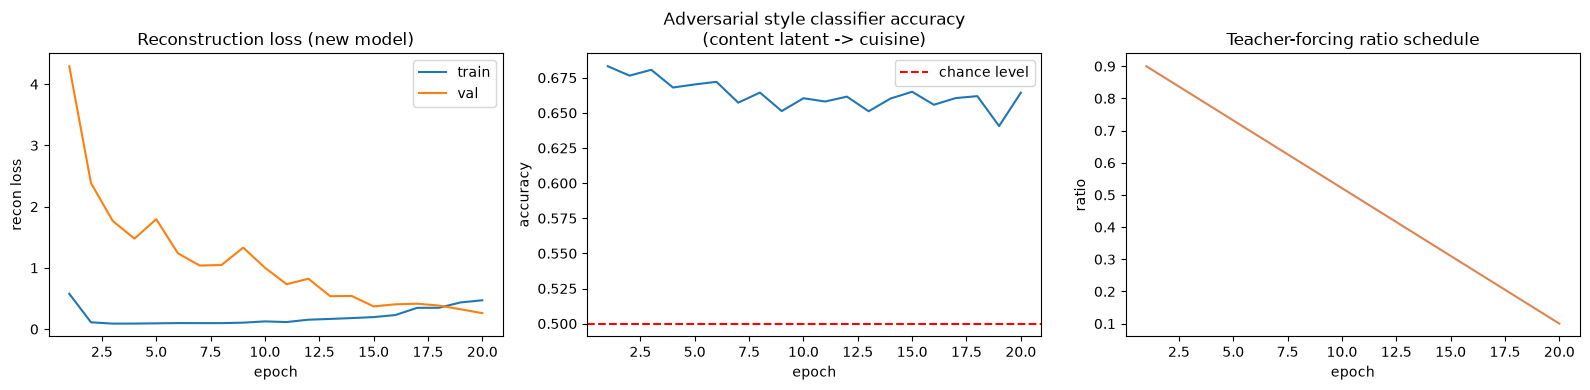

In [9]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(loss_history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_df['epoch'], history_df['recon_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_recon_loss'], label='val')
axes[0].set_title('Reconstruction loss (new model)')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('recon loss'); axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['adv_style_clf_acc'])
axes[1].axhline(0.5, color='red', linestyle='--', label='chance level')
axes[1].set_title('Adversarial style classifier accuracy\n(content latent -> cuisine)')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['teacher_forcing_ratio'], color='#DD8452')
axes[2].set_title('Teacher-forcing ratio schedule')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('ratio')

plt.tight_layout()
plt.show()

## Held-out test set evaluation (new model)

In [10]:
model.eval(); style_classifier.eval(); adv_style_classifier.eval()
total_recon, correct_style, correct_adv_style, n_batches, n_rows = 0.0, 0, 0, 0, 0
with torch.no_grad():
    for batch_x, batch_y, batch_len, batch_style, batch_bow in test_loader:
        batch_x, batch_y, batch_style = batch_x.to(device), batch_y.to(device), batch_style.to(device)
        log_probs, style_latent, content_latent = model(
            batch_x, batch_len, source_ids=batch_y, target=batch_y, teacher_forcing_ratio=0.0, return_latents=True
        )
        total_recon += recon_criterion(log_probs.permute(0, 2, 1), batch_y).item()
        correct_style += (style_classifier(style_latent).argmax(dim=-1) == batch_style).sum().item()
        correct_adv_style += (adv_style_classifier(content_latent).argmax(dim=-1) == batch_style).sum().item()
        n_batches += 1
        n_rows += batch_style.size(0)

new_test_recon_loss = total_recon / n_batches
new_style_acc = correct_style / n_rows
new_adv_style_acc = correct_adv_style / n_rows
print(f'[new model] test recon loss: {new_test_recon_loss:.4f}')
print(f'[new model] style_clf accuracy (style latent -> cuisine): {new_style_acc:.4f}')
print(f'[new model] adv_style_clf accuracy (content latent -> cuisine, chance = 0.5): {new_adv_style_acc:.4f}')

[new model] test recon loss: 0.3452
[new model] style_clf accuracy (style latent -> cuisine): 0.9276
[new model] adv_style_clf accuracy (content latent -> cuisine, chance = 0.5): 0.7315


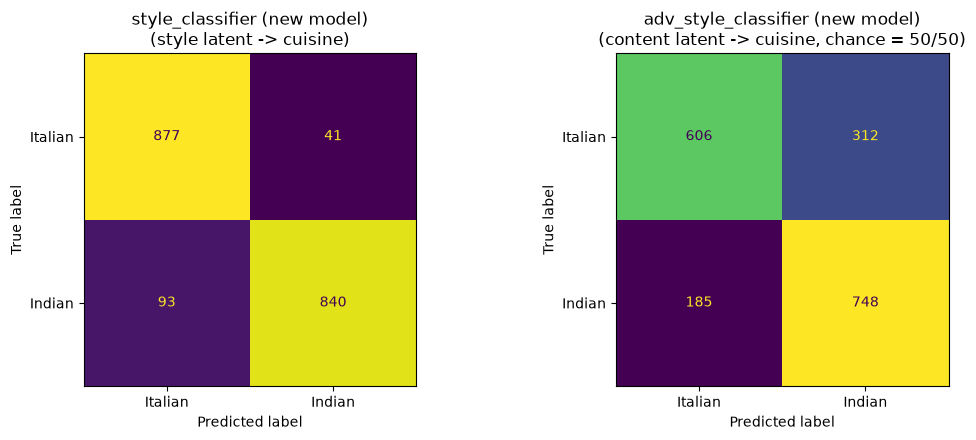

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

@torch.no_grad()
def collect_test_predictions_attn(model, style_classifier, adv_style_classifier, test_loader, device):
    model.eval(); style_classifier.eval(); adv_style_classifier.eval()
    y_true, style_pred, adv_style_pred = [], [], []
    for batch_x, batch_y, batch_len, batch_style, _ in test_loader:
        batch_x = batch_x.to(device)
        style_latent, content_latent, _ = model.encoder(batch_x, batch_len)
        y_true.extend(batch_style.tolist())
        style_pred.extend(style_classifier(style_latent).argmax(dim=-1).cpu().tolist())
        adv_style_pred.extend(adv_style_classifier(content_latent).argmax(dim=-1).cpu().tolist())
    return y_true, style_pred, adv_style_pred

y_true, style_pred, adv_style_pred = collect_test_predictions_attn(model, style_classifier, adv_style_classifier, test_loader, device)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_true, style_pred, display_labels=['Italian', 'Indian'], ax=axes[0], colorbar=False)
axes[0].set_title('style_classifier (new model)\n(style latent -> cuisine)')
ConfusionMatrixDisplay.from_predictions(y_true, adv_style_pred, display_labels=['Italian', 'Indian'], ax=axes[1], colorbar=False)
axes[1].set_title('adv_style_classifier (new model)\n(content latent -> cuisine, chance = 50/50)')
plt.tight_layout()
plt.show()

## Style transfer with the new model

Same idea as `02_model.ipynb`: average style latents per cuisine, then decode the *source* recipe's content (its `content_latent` **and** its per-position `content_states`/`source_ids`, so attention and copying still reference the original recipe) glued to the *target* cuisine's average style vector.

In [12]:
@torch.no_grad()
def compute_class_style_vectors_attn(model, dataset, cuisine2idx, device, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    style_sums = {idx: torch.zeros(model.encoder.style_dim, device=device) for idx in cuisine2idx.values()}
    style_counts = {idx: 0 for idx in cuisine2idx.values()}
    model.eval()
    for batch_x, _, batch_len, batch_style, _ in loader:
        batch_x, batch_style = batch_x.to(device), batch_style.to(device)
        style_latent, _, _ = model.encoder(batch_x, batch_len)
        for cls_idx in style_counts:
            mask = batch_style == cls_idx
            if mask.any():
                style_sums[cls_idx] += style_latent[mask].sum(dim=0)
                style_counts[cls_idx] += mask.sum().item()
    return {idx: style_sums[idx] / style_counts[idx] for idx in style_counts}

class_style_vectors_new = compute_class_style_vectors_attn(model, train_dataset, CUISINE2IDX, device)
for idx, vec in class_style_vectors_new.items():
    torch.save(vec, f'./data/models/style_avg_{IDX2CUISINE[idx].lower()}_attn.pt')
    print(f"{IDX2CUISINE[idx]}: style vector norm = {vec.norm().item():.4f}")

@torch.no_grad()
def transfer_style_attn(model, tokens, wv, word2idx, seq_len, target_style_vector, device):
    model.eval()
    x = tokens_to_matrix(tokens, wv, seq_len)
    x = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    length = torch.tensor([max(1, min(len(tokens), seq_len))], dtype=torch.long)
    source_ids = torch.tensor([tokens_to_indices(tokens, word2idx, seq_len)], dtype=torch.long, device=device)

    style_latent, content_latent, content_states = model.encoder(x, length)
    seq_len_actual = content_states.size(1)
    mask_len = length.clamp(max=seq_len_actual - 1).to(device)
    mask = torch.arange(seq_len_actual, device=device).unsqueeze(0) < mask_len.unsqueeze(1)
    hidden0 = torch.cat([target_style_vector.unsqueeze(0), content_latent], dim=-1)
    log_probs = model.decoder(
        hidden0, content_states, source_ids, mask,
        target=None, teacher_forcing_ratio=0.0, no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
    )
    predicted_indices = log_probs.argmax(dim=-1).squeeze(0).tolist()
    return indices_to_tokens(predicted_indices)

OPPOSITE_CUISINE = {'Italian': 'Indian', 'Indian': 'Italian'}
N_PER_CUISINE = 6
demo_samples = pd.concat([
    g.sample(n=min(N_PER_CUISINE, len(g)), random_state=42)
    for _, g in val_df.groupby('cuisine')
]).join(df_final)
demo_samples['target_cuisine'] = demo_samples['cuisine'].map(OPPOSITE_CUISINE)

generated_texts_new = [
    ' '.join(transfer_style_attn(
        model, row['steps_tokens'], wv, word2idx, seq_len,
        class_style_vectors_new[CUISINE2IDX[row['target_cuisine']]], device,
    ))
    for _, row in demo_samples.iterrows()
]

results_new = pd.DataFrame({
    'recipe_name': demo_samples['name'].tolist(),
    'original_cuisine': demo_samples['cuisine'].tolist(),
    'original_text': demo_samples['steps'].tolist(),
    'generated_text': generated_texts_new,
    'target_cuisine': demo_samples['target_cuisine'].tolist(),
})
results_new.to_csv('./data/style_transfer_results_attn.csv')

for _, row in results_new.head(4).iterrows():
    print(f"\n{row['recipe_name']} ({row['original_cuisine']} -> {row['target_cuisine']})")
    print('ORIGINAL:   ', row['original_text'])
    print('TRANSFERRED:', row['generated_text'])

Italian: style vector norm = 13.5769
Indian: style vector norm = 11.6968

roasted red bell pepper butter (Indian -> Italian)
ORIGINAL:    cut bell pepper in half. grill, turning oregularly, until the skin is blackened. remove from heat. place in a plastic sandwich bag for 15 minutes. remove bell pepper from bag after 15 minutes and peel it to remove stalk and seeds. slice thinly. combine bell pepper with lemon juice and salt. process till it becomes a smooth paste in your blender or mixer. add butter, pepper and dried basil. mix well. for a smooth paste, blend in a little olive oil, a tsp. at a time, until the ingredients hold together. serve with fish, vegetables or on warm bread. store this butter refrigerated for upto 1 week and frozen for upto 1 month.
TRANSFERRED: cut bell pepper in half grill turning in until the skin is blackened remove from heat place in a plastic sandwich bag for 15 minutes remove bell pepper from bag after 15 minutes and peel it to remove stalk and seeds slic

## Independent evaluation classifier

Same idea and same architecture as `02_model.ipynb`'s: trained only on real (non-transferred) recipe text, averaged Word2Vec features — never touches either model's latents. Trained once here and reused to score **both** the new model and the reloaded baseline below, so "transfer strength" numbers for the two are judged by the exact same, unbiased referee.

In [13]:
def recipe_to_avg_vector(tokens, wv):
    vectors = [wv[t] for t in tokens if t in wv]
    if not vectors:
        return np.zeros(wv.vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0).astype(np.float32)

def build_eval_features(df, wv):
    X = np.stack([recipe_to_avg_vector(tokens, wv) for tokens in df['steps_tokens']])
    y = np.array([CUISINE2IDX[c] for c in df['cuisine']], dtype=np.int64)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_eval_train, y_eval_train = build_eval_features(train_df, wv)
X_eval_val, y_eval_val = build_eval_features(val_df, wv)
X_eval_train, y_eval_train = X_eval_train.to(device), y_eval_train.to(device)
X_eval_val, y_eval_val = X_eval_val.to(device), y_eval_val.to(device)

class StyleEvalClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, len(CUISINE2IDX)))
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
eval_classifier = StyleEvalClassifier(wv.vector_size).to(device)
eval_optimizer = torch.optim.Adam(eval_classifier.parameters(), lr=1e-3)
eval_criterion = nn.CrossEntropyLoss()

EVAL_EPOCHS = 30
EVAL_BATCH_SIZE = 64
for epoch in range(1, EVAL_EPOCHS + 1):
    eval_classifier.train()
    perm = torch.randperm(X_eval_train.size(0))
    total_loss = 0.0
    for start in range(0, X_eval_train.size(0), EVAL_BATCH_SIZE):
        idx = perm[start:start + EVAL_BATCH_SIZE]
        batch_x, batch_y = X_eval_train[idx], y_eval_train[idx]
        eval_optimizer.zero_grad()
        loss = eval_criterion(eval_classifier(batch_x), batch_y)
        loss.backward()
        eval_optimizer.step()
        total_loss += loss.item() * batch_x.size(0)
    if epoch % 10 == 0 or epoch == EVAL_EPOCHS:
        eval_classifier.eval()
        with torch.no_grad():
            val_acc = (eval_classifier(X_eval_val).argmax(dim=-1) == y_eval_val).float().mean().item()
        print(f"epoch {epoch:3d} | train_loss {total_loss / X_eval_train.size(0):.4f} | val_acc {val_acc:.4f}")

epoch  10 | train_loss 0.1422 | val_acc 0.9379
epoch  20 | train_loss 0.1105 | val_acc 0.9427
epoch  30 | train_loss 0.0839 | val_acc 0.9422


In [ ]:
def bow_presence_vector(tokens, vectorizer):
    return (vectorizer.transform([tokens]).toarray().ravel() > 0)

def content_preservation_f1(original_bow_tokens, generated_tokens, vectorizer):
    original_vec = bow_presence_vector(original_bow_tokens, vectorizer)
    generated_vec = bow_presence_vector(generated_tokens, vectorizer)
    tp = np.logical_and(original_vec, generated_vec).sum()
    if tp == 0:
        return 0.0
    precision = tp / generated_vec.sum()
    recall = tp / original_vec.sum()
    return 2 * precision * recall / (precision + recall)

@torch.no_grad()
def score_transfer_strength_attn(model, eval_classifier, df, wv, word2idx, seq_len, class_style_vectors, cuisine2idx, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    correct = total = 0
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style_attn(model, row['steps_tokens'], wv, word2idx, seq_len, class_style_vectors[target_idx], device)
        feature = torch.tensor(recipe_to_avg_vector(transferred_tokens, wv), dtype=torch.float32, device=device).unsqueeze(0)
        predicted_idx = eval_classifier(feature).argmax(dim=-1).item()
        correct += int(predicted_idx == target_idx)
        total += 1
    return correct / total

@torch.no_grad()
def score_content_preservation_attn(model, df, wv, word2idx, seq_len, class_style_vectors, cuisine2idx, vectorizer, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    scores = []
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style_attn(model, row['steps_tokens'], wv, word2idx, seq_len, class_style_vectors[target_idx], device)
        scores.append(content_preservation_f1(row['steps_tokens_bow'], transferred_tokens, vectorizer))
    return float(np.mean(scores))

new_transfer_strength = score_transfer_strength_attn(model, eval_classifier, val_df, wv, word2idx, seq_len, class_style_vectors_new, CUISINE2IDX, device)
new_content_preservation = score_content_preservation_attn(model, val_df, wv, word2idx, seq_len, class_style_vectors_new, CUISINE2IDX, vectorizer, device)
print(f"[new model] transfer strength: {new_transfer_strength:.4f}")
print(f"[new model] content preservation F1: {new_content_preservation:.4f}")

## Reload the *original* best model for a fair, freshly-computed baseline

Rather than copying numbers from the README (which could drift out of sync, or be scored on a different random sample), the original architecture is redefined here verbatim and `checkpoint_best_recon.pt` is reloaded, then scored with the exact same held-out sample (`random_state=42`, `sample_size=200`) and the exact same independent `eval_classifier` trained above.

In [ ]:
class GRUEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, style_dim, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.style_dim = style_dim
        self.content_dim = hidden_dim - style_dim
        self.style_head = nn.Linear(hidden_dim, style_dim)
        self.content_head = nn.Linear(hidden_dim, self.content_dim)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        hidden = hidden.squeeze(0)
        hidden = self.dropout(hidden)
        style_latent = self.style_head(hidden)
        content_latent = self.content_head(hidden)
        return style_latent, content_latent

def block_repeat_ngrams(logits_t, generated, ngram_size):
    for b in range(logits_t.size(0)):
        seq = generated[b]
        if seq:
            logits_t[b, seq[-1]] = float('-inf')
        if len(seq) < ngram_size - 1:
            continue
        prefix = tuple(seq[-(ngram_size - 1):])
        banned = {seq[i + ngram_size - 1] for i in range(len(seq) - ngram_size + 1) if tuple(seq[i:i + ngram_size - 1]) == prefix}
        if banned:
            logits_t[b, list(banned)] = float('-inf')
    return logits_t

class GRUDecoder(nn.Module):
    def __init__(self, hidden_dim, vocab_size, embed_dim, sos_idx, pad_idx, unk_idx, max_len, dropout=0.2):
        super().__init__()
        self.max_len = max_len
        self.sos_idx = sos_idx
        self.unk_idx = unk_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.gru_cell = nn.GRUCell(embed_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, hidden, target=None, teacher_forcing_ratio=0.5, no_repeat_ngram_size=0):
        batch_size = hidden.size(0)
        device = hidden.device
        max_len = target.size(1) if target is not None else self.max_len
        input_idx = torch.full((batch_size,), self.sos_idx, dtype=torch.long, device=device)
        h = hidden
        outputs = []
        generated = [[] for _ in range(batch_size)] if no_repeat_ngram_size > 0 else None
        for t in range(max_len):
            embedded = self.embedding(input_idx)
            embedded = self.dropout(embedded)
            h = self.gru_cell(embedded, h)
            logits_t = self.fc_out(h)
            use_teacher_forcing = target is not None and torch.rand(1).item() < teacher_forcing_ratio
            if use_teacher_forcing:
                outputs.append(logits_t.unsqueeze(1))
                input_idx = target[:, t]
            else:
                if target is None:
                    logits_t[:, self.unk_idx] = float('-inf')
                    if no_repeat_ngram_size > 0:
                        logits_t = block_repeat_ngrams(logits_t, generated, no_repeat_ngram_size)
                outputs.append(logits_t.unsqueeze(1))
                input_idx = logits_t.argmax(dim=-1)
                if no_repeat_ngram_size > 0:
                    for b in range(batch_size):
                        generated[b].append(input_idx[b].item())
        return torch.cat(outputs, dim=1)

class Seq2SeqAutoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x, lengths, target=None, teacher_forcing_ratio=0.5, no_repeat_ngram_size=0, return_latents=False):
        style_latent, content_latent = self.encoder(x, lengths)
        context = torch.cat([style_latent, content_latent], dim=-1)
        logits = self.decoder(context, target=target, teacher_forcing_ratio=teacher_forcing_ratio, no_repeat_ngram_size=no_repeat_ngram_size)
        if return_latents:
            return logits, style_latent, content_latent
        return logits

baseline_checkpoint = torch.load('./data/models/checkpoint_best_recon.pt', map_location=device, weights_only=False)
bp = baseline_checkpoint['hparams']

baseline_encoder = GRUEncoder(bp['input_dim'], bp['hidden_dim'], bp['style_dim'], dropout=0.2).to(device)
baseline_decoder = GRUDecoder(bp['hidden_dim'], bp['vocab_size'], bp['input_dim'], bp['sos_idx'], bp['pad_idx'], bp['unk_idx'], bp['seq_len'], dropout=0.2).to(device)
baseline_model = Seq2SeqAutoencoder(baseline_encoder, baseline_decoder).to(device)
baseline_model.load_state_dict(baseline_checkpoint['model'])

baseline_style_classifier = nn.Linear(bp['style_dim'], len(CUISINE2IDX)).to(device)
baseline_style_classifier.load_state_dict(baseline_checkpoint['style_classifier'])
baseline_adv_style_classifier = nn.Sequential(
    nn.Linear(baseline_encoder.content_dim, bp['hidden_dim']), nn.ReLU(), nn.Linear(bp['hidden_dim'], len(CUISINE2IDX))
).to(device)
baseline_adv_style_classifier.load_state_dict(baseline_checkpoint['adv_style_classifier'])

baseline_model.eval(); baseline_style_classifier.eval(); baseline_adv_style_classifier.eval()

baseline_recon_criterion = nn.CrossEntropyLoss(ignore_index=bp['pad_idx'])

total_recon, correct_style, correct_adv_style, n_batches, n_rows = 0.0, 0, 0, 0, 0
with torch.no_grad():
    for batch_x, batch_y, batch_len, batch_style, batch_bow in test_loader:
        batch_x, batch_y, batch_style = batch_x.to(device), batch_y.to(device), batch_style.to(device)
        logits, style_latent, content_latent = baseline_model(batch_x, batch_len, target=batch_y, teacher_forcing_ratio=0.0, return_latents=True)
        total_recon += baseline_recon_criterion(logits.permute(0, 2, 1), batch_y).item()
        correct_style += (baseline_style_classifier(style_latent).argmax(dim=-1) == batch_style).sum().item()
        correct_adv_style += (baseline_adv_style_classifier(content_latent).argmax(dim=-1) == batch_style).sum().item()
        n_batches += 1
        n_rows += batch_style.size(0)

baseline_test_recon_loss = total_recon / n_batches
baseline_style_acc = correct_style / n_rows
baseline_adv_style_acc = correct_adv_style / n_rows
print(f'[baseline] test recon loss: {baseline_test_recon_loss:.4f}')
print(f'[baseline] style_clf accuracy: {baseline_style_acc:.4f}')
print(f'[baseline] adv_style_clf accuracy (chance = 0.5): {baseline_adv_style_acc:.4f}')

In [ ]:
@torch.no_grad()
def transfer_style_baseline(model, tokens, wv, seq_len, target_style_vector, device):
    model.eval()
    x = tokens_to_matrix(tokens, wv, seq_len)
    x = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    length = torch.tensor([max(1, min(len(tokens), seq_len))], dtype=torch.long)
    _, content_latent = model.encoder(x, length)
    context = torch.cat([target_style_vector.unsqueeze(0), content_latent], dim=-1)
    logits = model.decoder(context, target=None, teacher_forcing_ratio=0.0, no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE)
    predicted_indices = logits.argmax(dim=-1).squeeze(0).tolist()
    return indices_to_tokens(predicted_indices)

baseline_style_italian = torch.load('./data/models/style_avg_italian.pt', map_location=device, weights_only=False)
baseline_style_indian = torch.load('./data/models/style_avg_indian.pt', map_location=device, weights_only=False)
baseline_class_style_vectors = {CUISINE2IDX['Italian']: baseline_style_italian, CUISINE2IDX['Indian']: baseline_style_indian}

@torch.no_grad()
def score_transfer_strength_baseline(model, eval_classifier, df, wv, seq_len, class_style_vectors, cuisine2idx, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    correct = total = 0
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style_baseline(model, row['steps_tokens'], wv, seq_len, class_style_vectors[target_idx], device)
        feature = torch.tensor(recipe_to_avg_vector(transferred_tokens, wv), dtype=torch.float32, device=device).unsqueeze(0)
        predicted_idx = eval_classifier(feature).argmax(dim=-1).item()
        correct += int(predicted_idx == target_idx)
        total += 1
    return correct / total

@torch.no_grad()
def score_content_preservation_baseline(model, df, wv, seq_len, class_style_vectors, cuisine2idx, vectorizer, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    scores = []
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style_baseline(model, row['steps_tokens'], wv, seq_len, class_style_vectors[target_idx], device)
        scores.append(content_preservation_f1(row['steps_tokens_bow'], transferred_tokens, vectorizer))
    return float(np.mean(scores))

baseline_transfer_strength = score_transfer_strength_baseline(baseline_model, eval_classifier, val_df, wv, bp['seq_len'], baseline_class_style_vectors, CUISINE2IDX, device)
baseline_content_preservation = score_content_preservation_baseline(baseline_model, val_df, wv, bp['seq_len'], baseline_class_style_vectors, CUISINE2IDX, vectorizer, device)
print(f"[baseline] transfer strength: {baseline_transfer_strength:.4f}")
print(f"[baseline] content preservation F1: {baseline_content_preservation:.4f}")

## Before vs. after

In [ ]:
summary = pd.DataFrame({
    'metric': ['Test recon loss (nats, lower better)', 'Style classifier accuracy', 'Adversarial probe accuracy (chance=0.5)', 'Transfer strength', 'Content preservation F1'],
    'baseline': [baseline_test_recon_loss, baseline_style_acc, baseline_adv_style_acc, baseline_transfer_strength, baseline_content_preservation],
    'new_model': [new_test_recon_loss, new_style_acc, new_adv_style_acc, new_transfer_strength, new_content_preservation],
})
summary['delta'] = summary['new_model'] - summary['baseline']
summary

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

def bar_pair(ax, title, baseline_val, new_val, chance_line=None):
    x = [0, 1]
    ax.bar(x, [baseline_val, new_val], color=['#4C72B0', '#DD8452'], width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(['baseline', 'new model'])
    for i, v in enumerate([baseline_val, new_val]):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    if chance_line is not None:
        ax.axhline(chance_line, color='gray', linestyle='--', linewidth=1)
    ax.set_title(title)

bar_pair(axes[0], 'Content preservation F1\n(the metric we set out to fix)', baseline_content_preservation, new_content_preservation)
bar_pair(axes[1], 'Transfer strength\n(did style transfer still work?)', baseline_transfer_strength, new_transfer_strength)
bar_pair(axes[2], 'Adversarial probe accuracy\n(chance = 0.5, lower = better disentangled)', baseline_adv_style_acc, new_adv_style_acc, chance_line=0.5)
bar_pair(axes[3], 'Test reconstruction loss\n(nats, lower is better)', baseline_test_recon_loss, new_test_recon_loss)

plt.tight_layout()
plt.savefig('./data/content_preservation_experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

**This didn't work — and not in a "modest tradeoff" way, in a "the mechanism broke the task" way.**

| Metric | Baseline | New model | |
|---|---|---|---|
| Content preservation F1 | 0.252 | **0.912** | looks like a huge win |
| Transfer strength | 0.960 | **0.030** | but this collapsed - below chance |
| Adversarial probe acc (chance = 0.5) | 0.530 | 0.565 | modestly worse, as expected from halving the adversarial weight |
| Test reconstruction loss | 6.020 | 0.217 | suspiciously good |

Looking at the actual transferred text explains why: recipes came back **almost word-for-word identical** to the original, regardless of which cuisine's style vector was attached (e.g. "bhindi bhaji" Indian → Italian reads nearly the same as the source). The model isn't preserving content *while still transferring style* - it mostly stopped transferring style at all, and the high F1 is just what you get when the output is nearly the same text as the input being scored for word overlap with itself.

**Root cause: the copy/pointer mechanism found a shortcut that's specific to this being an autoencoder, not a translation/summarization task.** In a typical pointer-generator setup, source and target are different sequences, so copying still forces the model to select *which* source words are relevant to the *current* target position. Here, training reconstructs the same recipe it was given, so target position *t* is (almost) always source position *t*'s own token - the model can drive reconstruction loss toward zero by learning "attend to my own same-index position and copy it," a trivial identity mapping that requires no real language understanding and has nothing to do with genuine content preservation. That shortcut also explains the too-good-to-be-true recon loss (6.02 → 0.22): it's not better reconstruction, it's a different, easier problem that the model discovered how to solve. And once the decoder learns it can just echo the input, the style latent it's handed at transfer time barely matters anymore - hence transfer strength crashing.

The adversarial probe and style classifier numbers barely moved (0.530 → 0.565, 93.6% → 92.9%), which is consistent with this: this run isn't really a disentanglement story, it's a "the copy mechanism ate the model" story. Changes 1/3/4/5 (attention, bigger content latent, retuned adversarial weight, teacher-forcing decay) were never really tested in isolation here, because change 2 (copy) dominated the outcome.

**What this rules in vs. rules out:**
- Ruled out: bundling a naive position-unrestricted copy mechanism into an autoencoding seq2seq objective. The identity shortcut is too easy for gradient descent to resist.
- Still untested: whether attention + bigger content latent + retuned adversarial weight + teacher-forcing decay help *without* the copy mechanism - that combination was never isolated from the shortcut here.
- A more surgical follow-up, if the copy mechanism is worth keeping: block a position from copying its own same-index source token during training, forcing any copying that does happen to come from *other* positions - which would remove the trivial echo path without discarding attention/copying altogether.

Net takeaway: content preservation is still an open problem. This experiment didn't solve it - it found a different way to score well on the metric while quietly abandoning the thing the metric was meant to measure.